# Importo las librerias

In [40]:
import os

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import chi2

In [41]:
#------Tamaño de letra en los ejes----------
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.labelsize'] = 16      # Tamaño de xlabel/ylabel
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['font.size'] = 14           # Tamaño base general

# Cargo las mediciones ya promediadas y con sus std

In [42]:
Ruta_mediciones = 'Mediciones'
archivos = os.listdir(Ruta_mediciones)

Elementos = [archivo for archivo in archivos if archivo[-6:] == 'pickle']

# Picos experimentales vs teóricos

## Busqueda de los experimentales y definición de los teóricos

Busco los picos experimentales de cada espectro y armo la figura

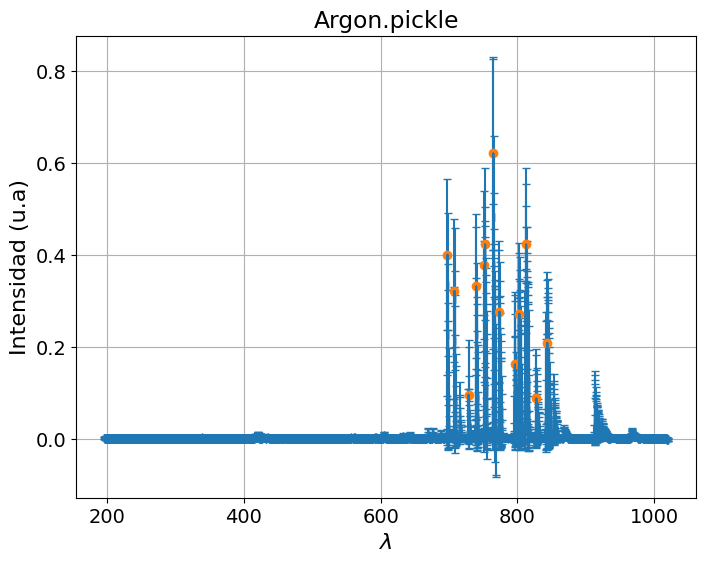

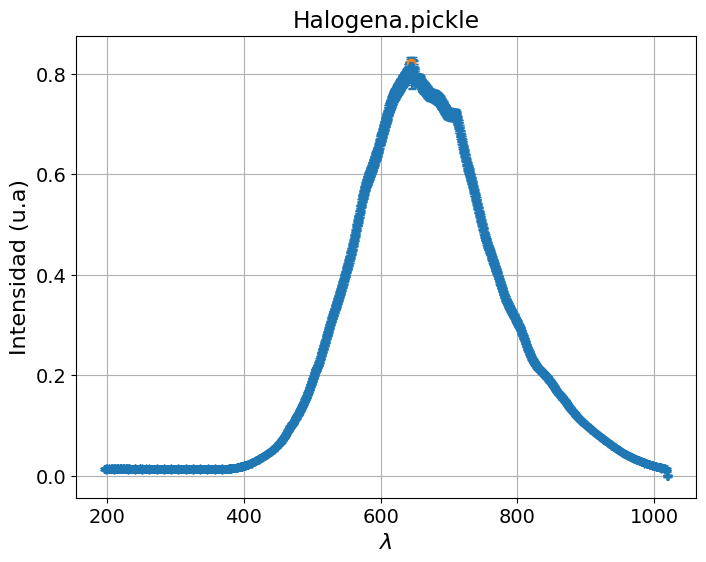

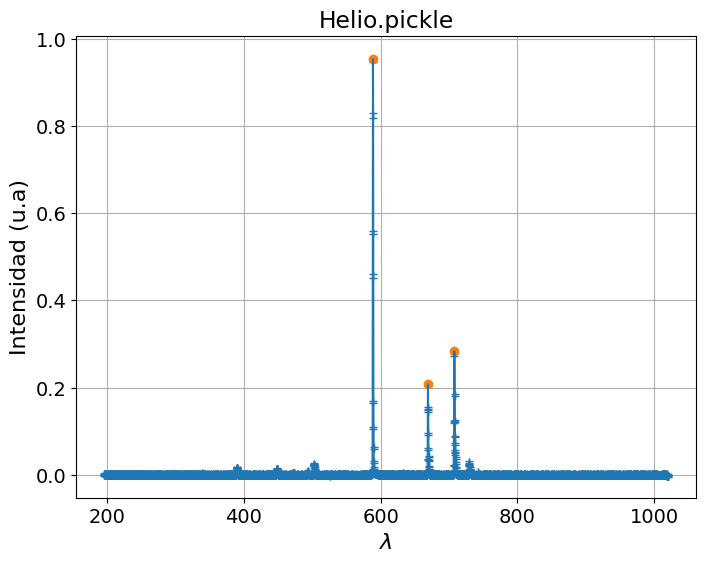

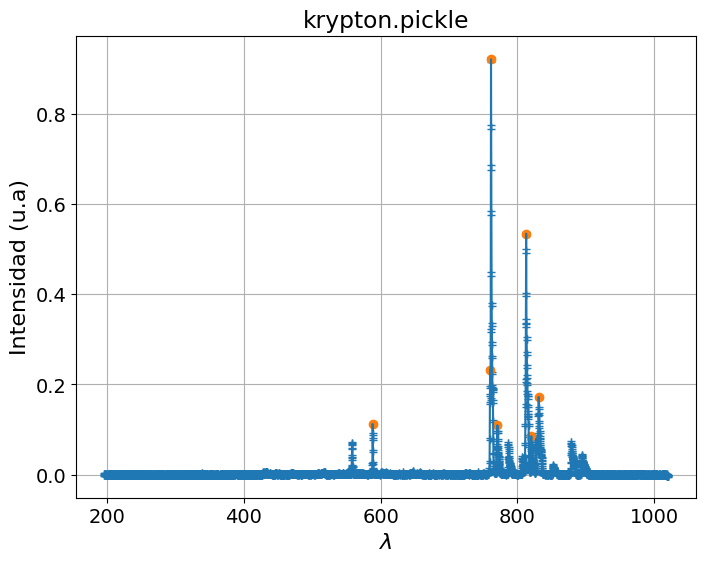

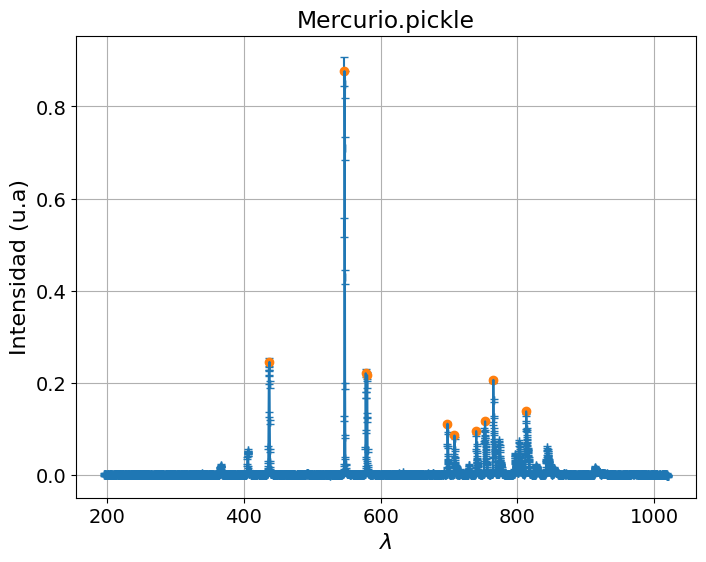

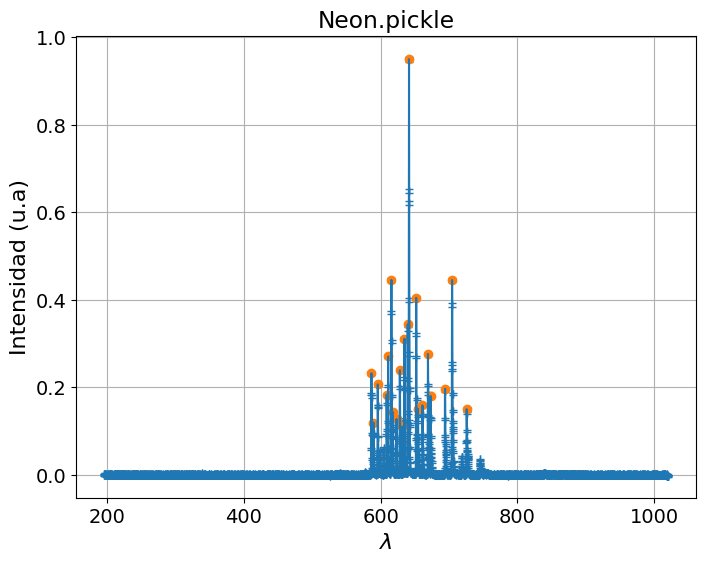

In [43]:
Emisiones_exp, err_Emisiones_exp, Intensidad_exp = [], [], [] #Intensidad solo sirve para el gráfico de despues
for elemento in Elementos:
    # Coloco en variables los datos
    df = pd.read_pickle('Mediciones/' + f'{elemento}')
    
    I, err_I = df['Intensidad'], df['err_Intensidad']
    Longitud, err_Longitud = df['Longitud_onda'], df['err_Longitud_onda']
    
    # Busco los picos
    peaks, _ = find_peaks(I, prominence = 0.05, height = 0.08)
    if elemento != 'Halogena.pickle':
        Emisiones_exp.append(Longitud[peaks]), err_Emisiones_exp.append(err_Longitud[peaks])
        Intensidad_exp.append(I[peaks])
    
    # Figuras correspondientes a los espectros de cada lampara
    plt.figure(figsize = (8, 6))

    plt.errorbar(Longitud, I, xerr = err_Longitud, yerr = err_I,
                    capsize = 3)
    plt.plot(Longitud[peaks], I[peaks], 'o')

    plt.title(elemento), plt.ylabel('Intensidad (u.a)'), plt.xlabel(r'$\lambda$')
    plt.grid()
    plt.show()

Emisiones_teo = [
    [696.543, 706.722, 714.704, 727.294, 738.398, 750.387, 
    751.465, 763.511, 772.376, 794.818, 800.615, 811.531, 826.452],
    [587.562, 667.816, 706.522],
    [587.613, 758.698, 760.135, 769.896, 811.531, 819.021, 830.436],
    [435.833, 546.074, 577.029, 579.065, 696.543, 706.522, 736.096, 752.575, 764.514, 811.262],
    [585.249, 587.562, 594.483, 607.434, 609.614, 615.422, 617.631, 622.718, 627.658, 631.899, 
    634.711, 638.299, 640.225, 650.652, 653.288, 659.895, 667.828, 672.556, 692.947, 703.241, 724.506]
] 

# Figuras de calibración

Defino una función para calcular $\chi^2_{\nu}$ en cada uno de los ajustes:

In [44]:
def obtener_chi2red(f, params, x:np.array, y:np.array, err_y:np.array) -> float:
    gl = len(y)
    chi2 = sum( ( (y - f(x, *params)) / err_y )**2 )
    
    return np.round(chi2/gl)

Observamos para cada uno de los elementos si la relación entre las mediciones experimentales y teóricas es lineal y responde 1 a 1. Para esto utilizamos la siguiente relación lineal:

$$f(x) = ax + b$$

C:\Users\User\AppData\Local\Temp\ipykernel_3316\355882010.py:3: RuntimeWarning: divide by zero encountered in divide
  chi2 = sum( ( (y - f(x, *params)) / err_y )**2 )


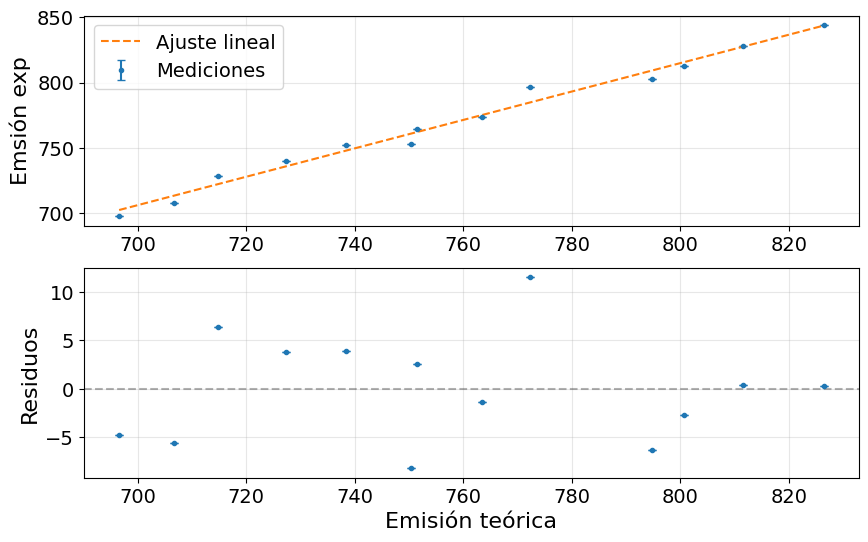

Argon.pickle
La pendiente es a = 1.085663526248367 +- 0.04080280500816711
La ordenada es b = -53.65313775006983 +- 30.973846069754714
inf


C:\Users\User\AppData\Local\Temp\ipykernel_3316\355882010.py:3: RuntimeWarning: divide by zero encountered in divide
  chi2 = sum( ( (y - f(x, *params)) / err_y )**2 )


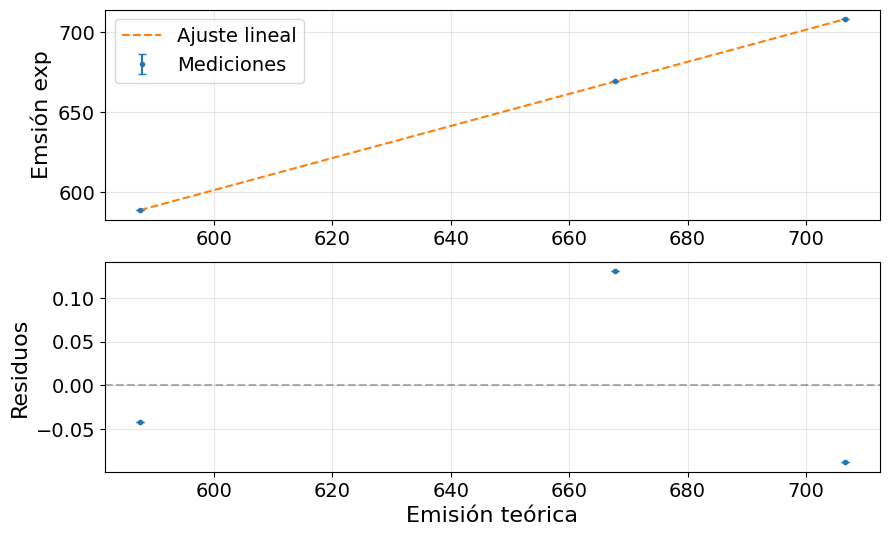

Helio.pickle
La pendiente es a = 0.9999669002884528 +- 0.0019035573670208444
La ordenada es b = 1.3740101747116167 +- 1.2484320000950815
inf


C:\Users\User\AppData\Local\Temp\ipykernel_3316\355882010.py:3: RuntimeWarning: divide by zero encountered in divide
  chi2 = sum( ( (y - f(x, *params)) / err_y )**2 )


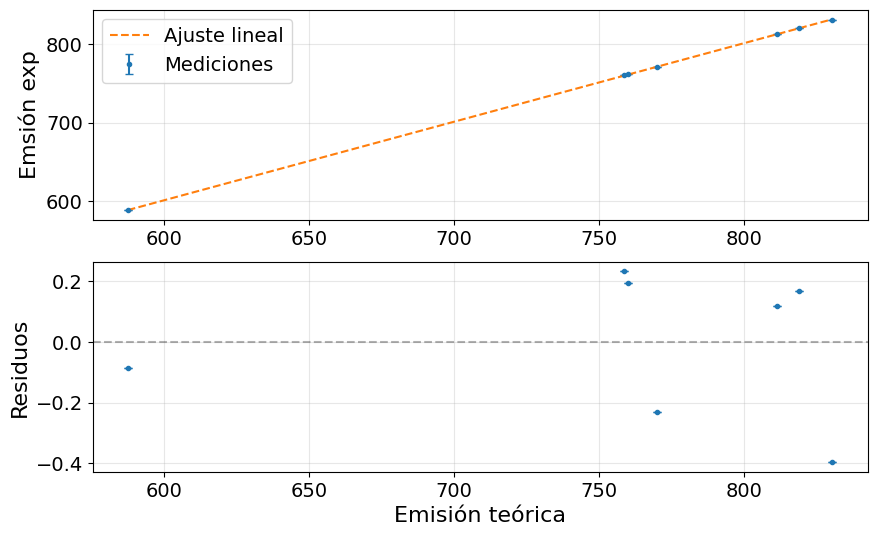

krypton.pickle
La pendiente es a = 1.0014852175812388 +- 0.0013076574666498163
La ordenada es b = 0.020880420629674212 +- 1.0019925453893086
inf


C:\Users\User\AppData\Local\Temp\ipykernel_3316\355882010.py:3: RuntimeWarning: divide by zero encountered in divide
  chi2 = sum( ( (y - f(x, *params)) / err_y )**2 )


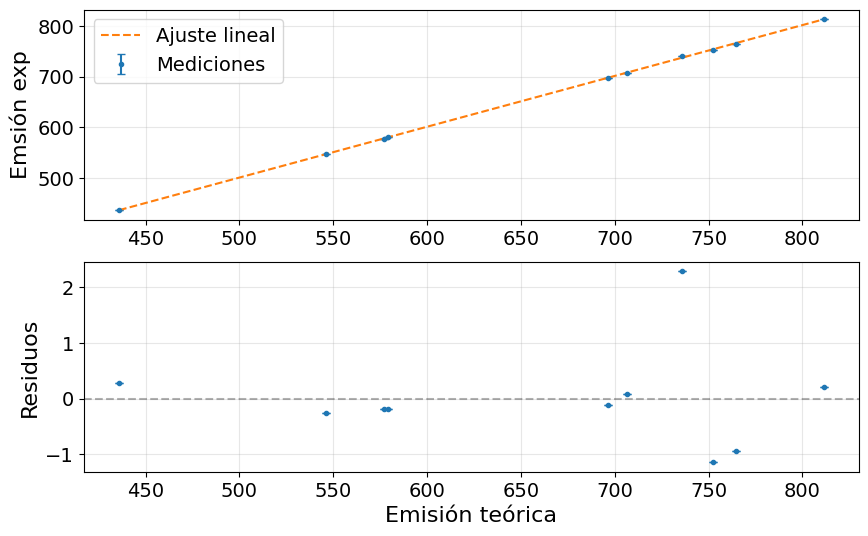

Mercurio.pickle
La pendiente es a = 0.9999565277646795 +- 0.002740844913302568
La ordenada es b = 1.4455125715570125 +- 1.8369006448850618
inf


C:\Users\User\AppData\Local\Temp\ipykernel_3316\355882010.py:3: RuntimeWarning: divide by zero encountered in divide
  chi2 = sum( ( (y - f(x, *params)) / err_y )**2 )


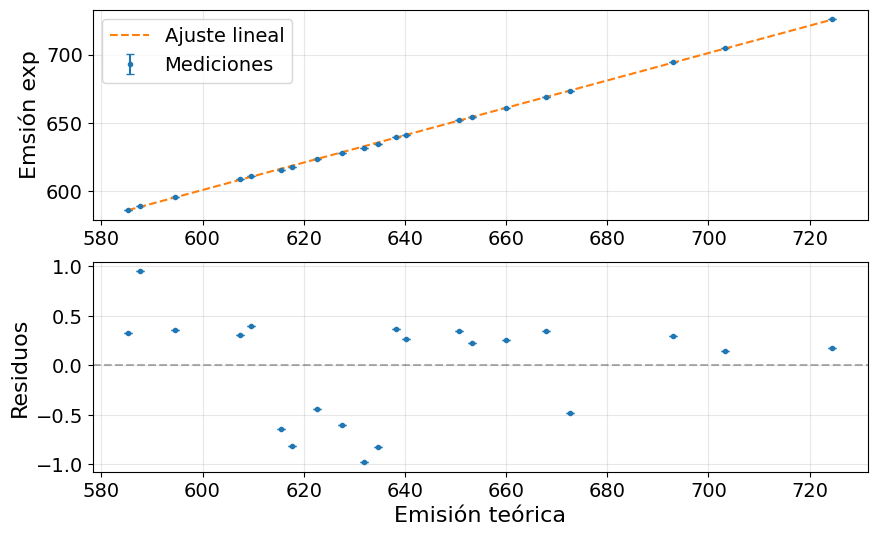

Neon.pickle
La pendiente es a = 1.0010178770308953 +- 0.003254577891354109
La ordenada es b = 0.4414259346272158 +- 2.0859547495547894
inf


In [45]:
f = lambda x, a, b: a*x + b
Elementos_figura_nombre = [elemento_nombre for elemento_nombre in Elementos if elemento_nombre != 'Halogena.pickle']
for emision_teo, emision_exp, err_emision_exp, elemento in zip(Emisiones_teo, Emisiones_exp, err_Emisiones_exp, Elementos_figura_nombre):
    # Paso a arrays por las dudas
    emision_exp, err_emision_exp = np.array(emision_exp), np.array(err_emision_exp)
    emision_teo = np.array(emision_teo)

    # Ajuste lineal
    popt, pcov = curve_fit(f, emision_teo, emision_exp)
    pcov = np.sqrt(np.diag(pcov))
    chi2 = obtener_chi2red(f, popt, emision_teo, emision_exp, err_emision_exp)

    fig, axs = plt.subplots(2, 1, figsize = (10, 6))

    axs[0].errorbar(emision_teo, emision_exp, yerr = err_emision_exp, 
                    fmt = '.', capsize = 3, label = 'Mediciones')
    axs[0].plot(emision_teo, f(emision_teo, *popt), '--', label = 'Ajuste lineal')
    axs[0].set(ylabel = 'Emsión exp'), axs[0].grid(alpha = 0.3)
    axs[0].legend()

    axs[1].errorbar(emision_teo, emision_exp - f(emision_teo, *popt),yerr = err_emision_exp,fmt = '.',capsize = 3)
    axs[1].set(xlabel = 'Emisión teórica', ylabel = 'Residuos')
    axs[1].axhline(0, linestyle = '--', color = 'black', alpha = .3)
    axs[1].grid(alpha = 0.3)

    plt.savefig(f'Figuras_informe/Calibraciones/{elemento[:-6]}pdf', bbox_inches = 'tight')
    plt.show()
    print(elemento)
    print(f'La pendiente es a = {popt[0]} +- {pcov[0]}')
    print(f'La ordenada es b = {popt[1]} +- {pcov[1]}')
    print(chi2)

